### Conversion

Convert, process, and export processed original data to a more structured and useful format (pandas DataFrame).

In [64]:
import importlib
import processing.conversion

importlib.reload(processing.conversion)

from processing.conversion import Conversion

c = Conversion(prefix='processing', subjects=['dwrotheos'])

c.cleanup_data() # cleans the data directory and prepares for processing
c.process_subjects(replace=False) # processes each subject and exports to txt files

Skipping dwrotheos as raw folder already exists

Processing data for dwrotheos
	Skipping 40.2.mat as it has already been processed
	Skipping 40.3.mat as it has already been processed
	Skipping 40.1.mat as it has already been processed
	Skipping 60.1.mat as it has already been processed
	Skipping 60.2.mat as it has already been processed
	Skipping 60.3.mat as it has already been processed
	Skipping 20.1.mat as it has already been processed
	Skipping 20.3.mat as it has already been processed
	Skipping 20.2.mat as it has already been processed
	Skipping 5.1.mat as it has already been processed
	Skipping 5.3.mat as it has already been processed
	Skipping 5.2.mat as it has already been processed
	Processing MVC.2.mat (MVC: 100, Trial: 2)...
	Processing MVC.1.mat (MVC: 100, Trial: 1)...
	Skipping 10.1.mat as it has already been processed
	Skipping 10.2.mat as it has already been processed
	Skipping 10.3.mat as it has already been processed
	Successfully processed data for dwrotheos


In [65]:
df = c.get_dataframe() # returns a pandas dataframe of the processed data
df

Loading data for dwrotheos...


,subject,mvc_level,trial_number,neuron_data,force_data
0,dwrotheos,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.006100465392304244, -0.0061004653..."
1,dwrotheos,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392304244, 0.006100465392300..."
2,dwrotheos,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392300691, 0.0, 0.00610046539..."
3,dwrotheos,10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.012200930784608488, 0.01220093078..."
4,dwrotheos,10,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.006100465392304244, 0.01220093078..."
5,dwrotheos,10,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392304244, 0.0, 0.0061004653..."
6,dwrotheos,20,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.0488037231384304, -0.0122009307846084..."
7,dwrotheos,20,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, -0.012200930784608488, -0.006100465..."
8,dwrotheos,20,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.030502326961517667, 0.006100465392304..."
9,dwrotheos,40,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392304244, -0.00610046539230..."


### Sanitization

Remove or correct any errors in the data. This includes removing outliers, filling in missing values, and correcting any other errors in the data. Some entries are not recoverable and will be "purged".

More information and specific algorithm implementations can be found [here](https://github.com/paul-bokelman/force-prediction/issues/3).

In [66]:
import importlib
import processing.sanitization
import processing.constants

importlib.reload(processing.sanitization)
importlib.reload(processing.constants)

from processing.sanitization import Sanitization

sanitizer = Sanitization(df=df)
df = sanitizer.sanitize()

Computing global statistics...
	Average max activation distance: 5574.0
	Max force data length: 87683
	Max number of neurons: 22
	Max number of activations: 87683
Global statistics computed.
Purging entries with insufficient neuron data...
Purged 3 entries with insufficient neuron data. 14 entries remaining.
Purging entries with inconsistent neuron data...
Purged 1 entries with inconsistent firing distances
Handling measurement correlation...
	[dwrotheos.5.1] Leading turn: 5.91064453125 | Trailing turn: 36.5341796875
	[dwrotheos.5.1] Flat Region Interval (Inflection Points): (6.88720703125, 33.25439453125)
	[dwrotheos.5.2] Both regions modified -> Skipping
	[dwrotheos.5.3] Both regions modified -> Skipping
	[dwrotheos.10.1] Both regions modified -> Skipping
	[dwrotheos.10.2] Both regions modified -> Skipping
	[dwrotheos.10.3] Leading turn: 6.2578125 | Trailing turn: 39.359375
	[dwrotheos.10.3] Flat Region Interval (Inflection Points): (9.1875, 38.484375)
	[dwrotheos.20.1] Both regions 

In [67]:
sanitizer.show_purged() # all entries removed during sanitization process

,subject,mvc_level,trial_number
12,dwrotheos,60,1
13,dwrotheos,60,2
15,dwrotheos,100,1
16,dwrotheos,100,2


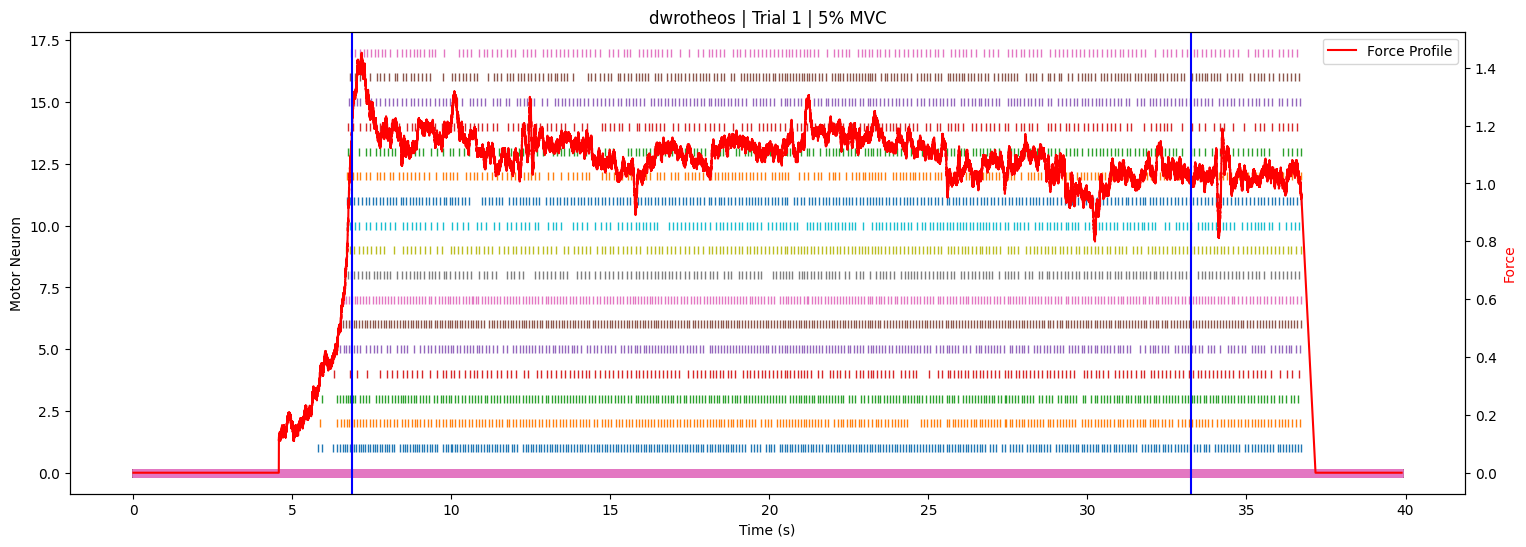

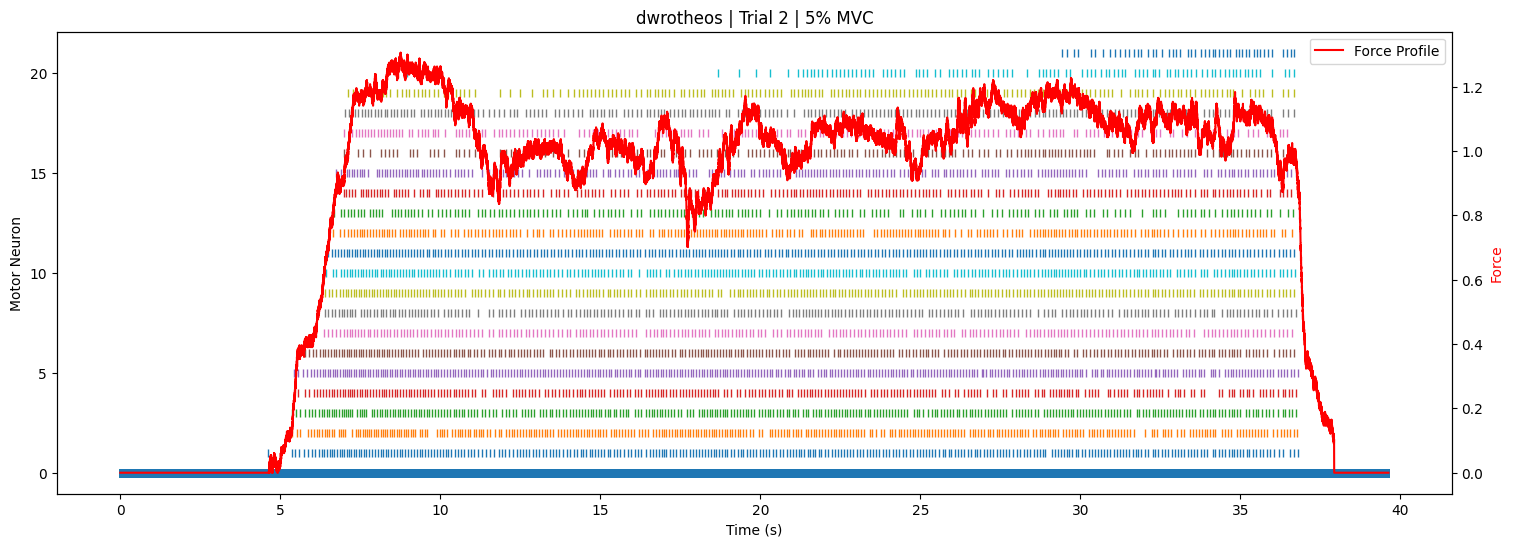

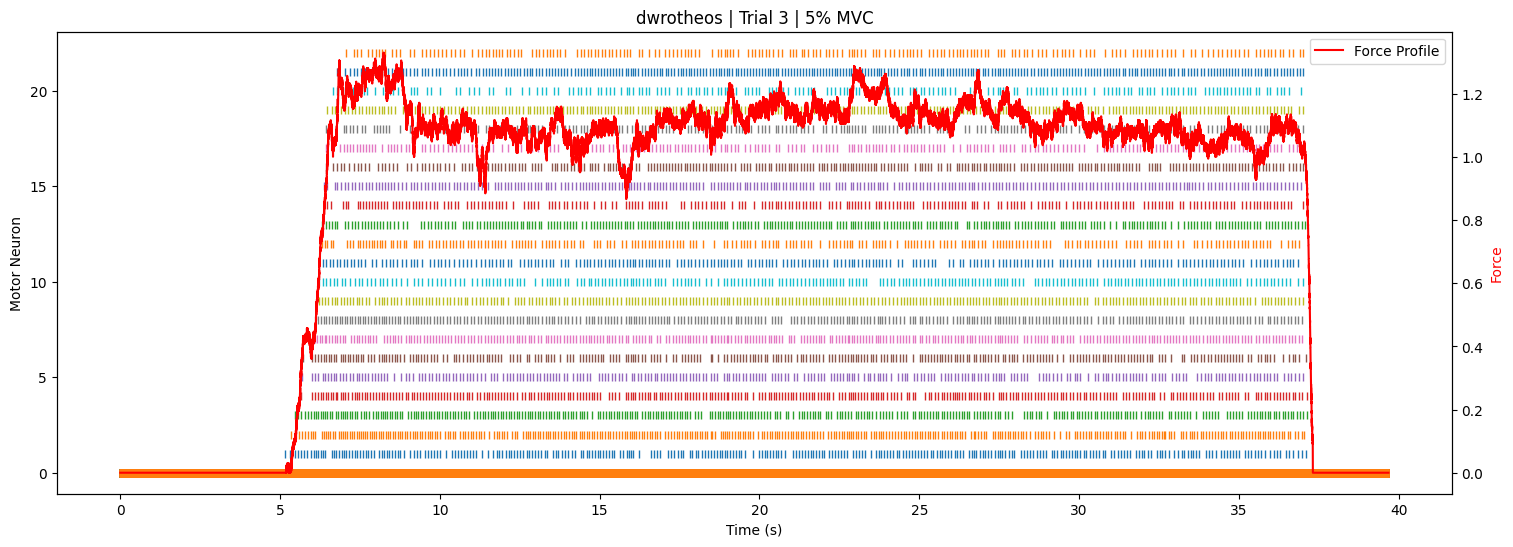

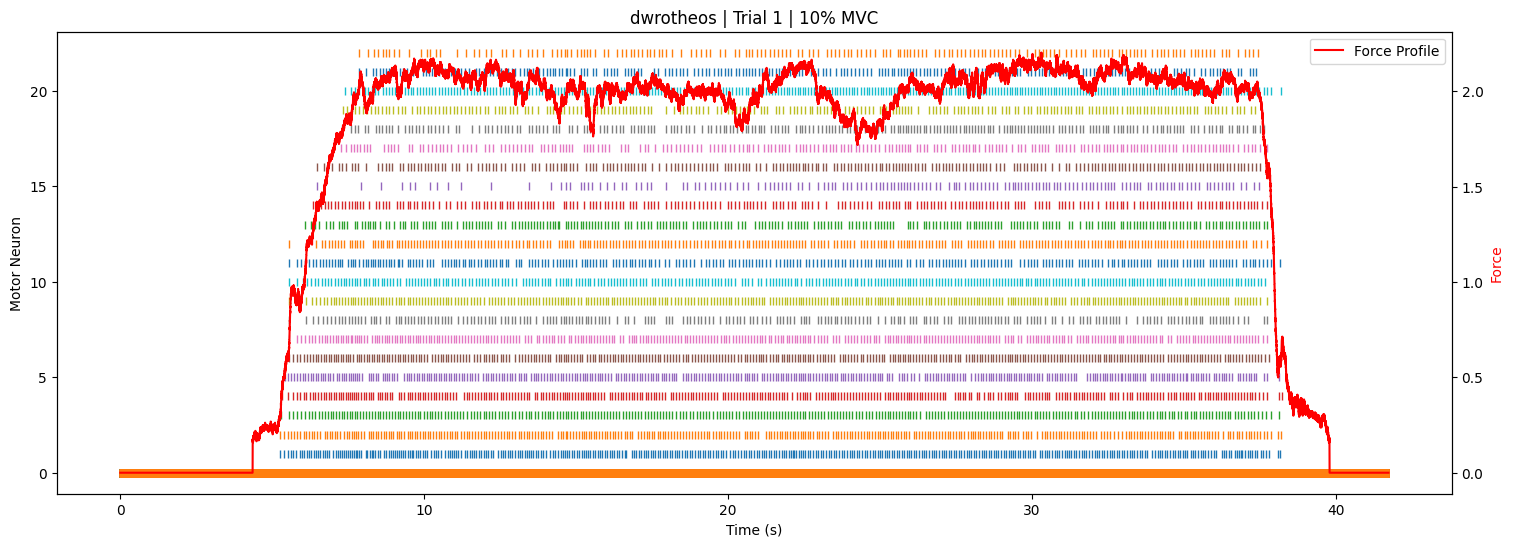

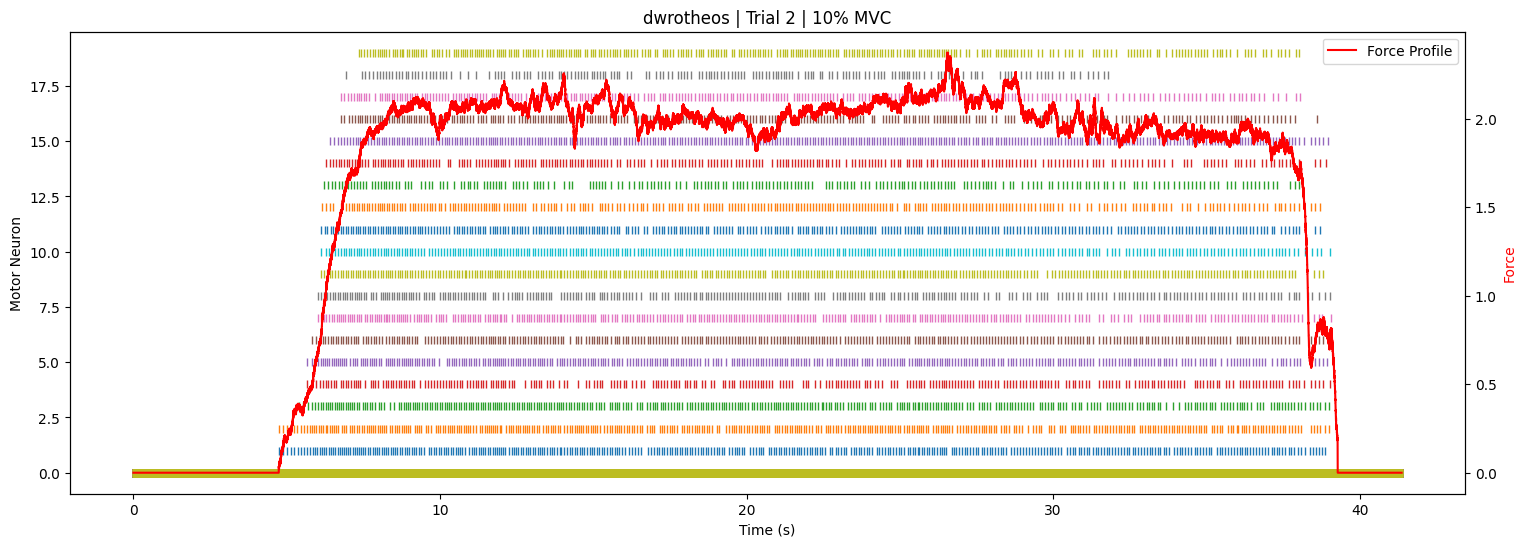

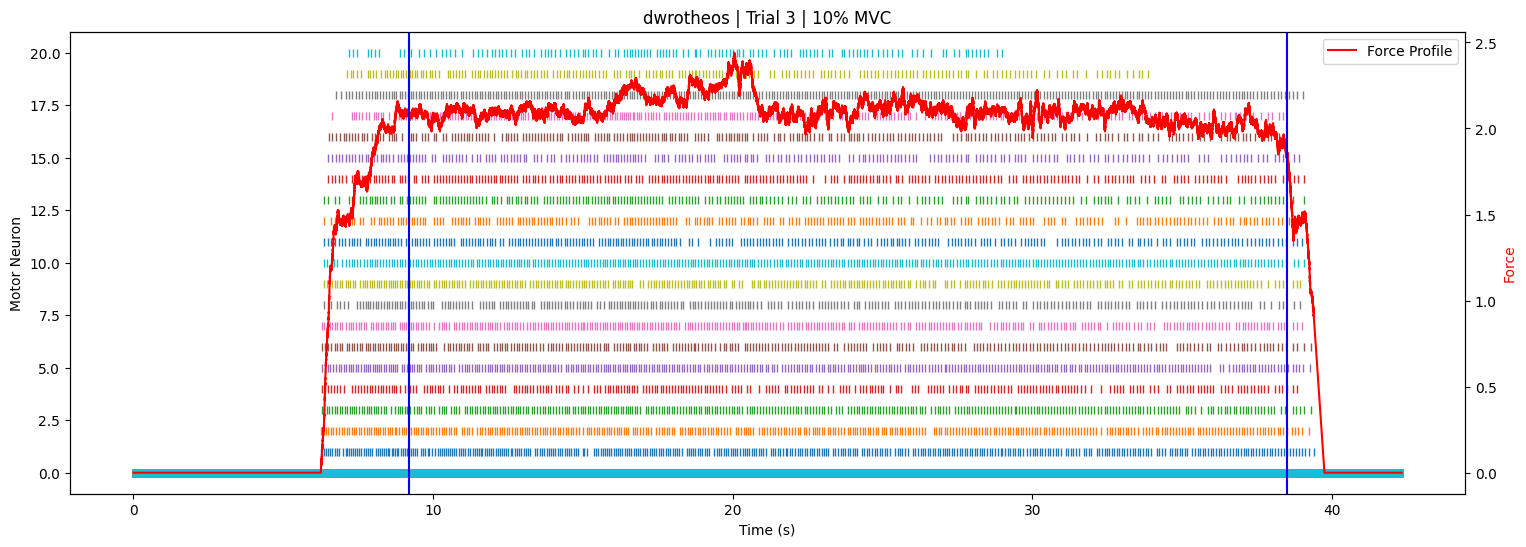

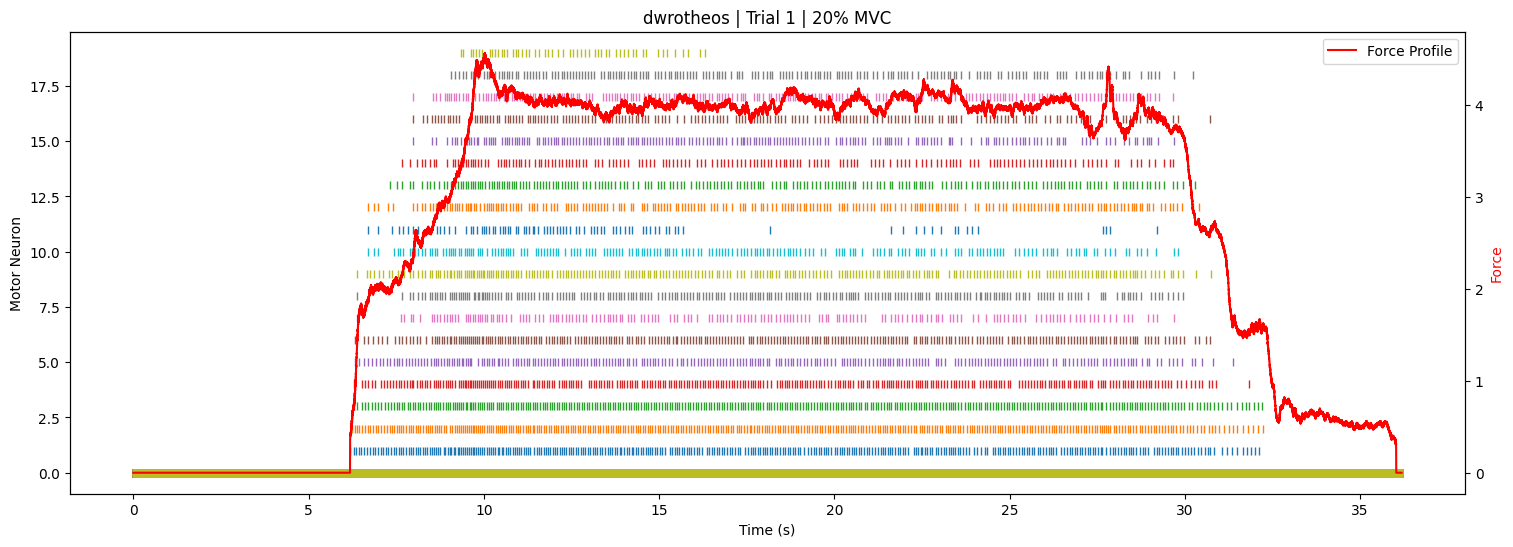

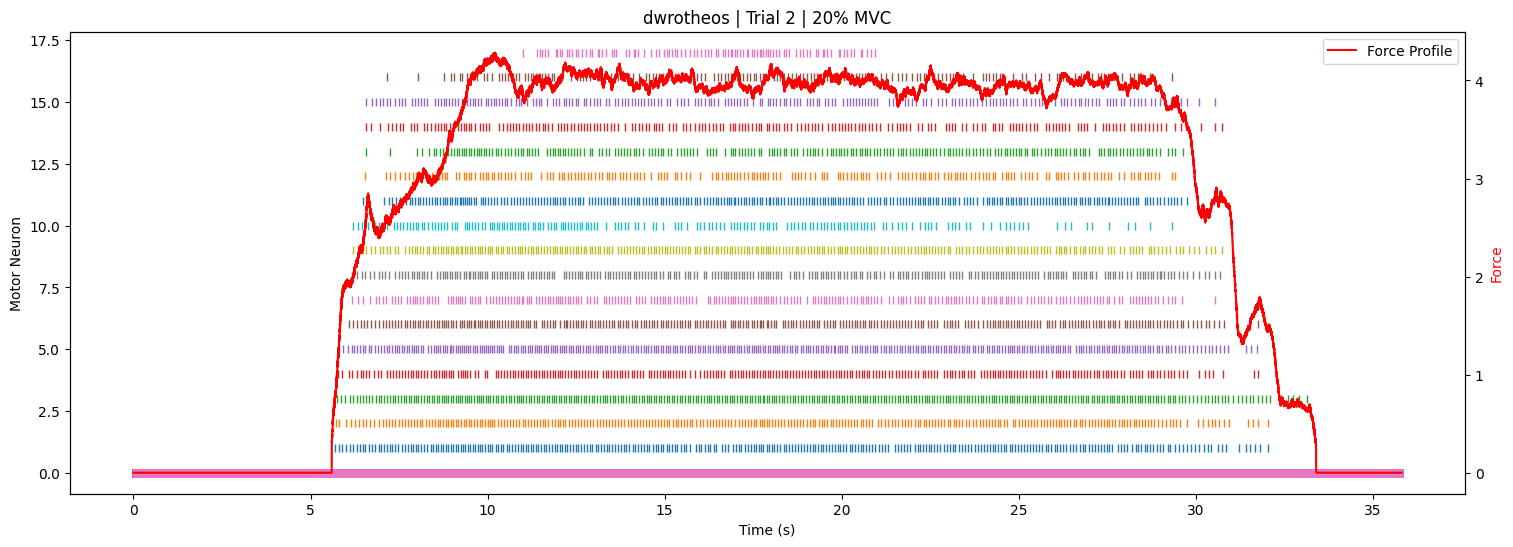

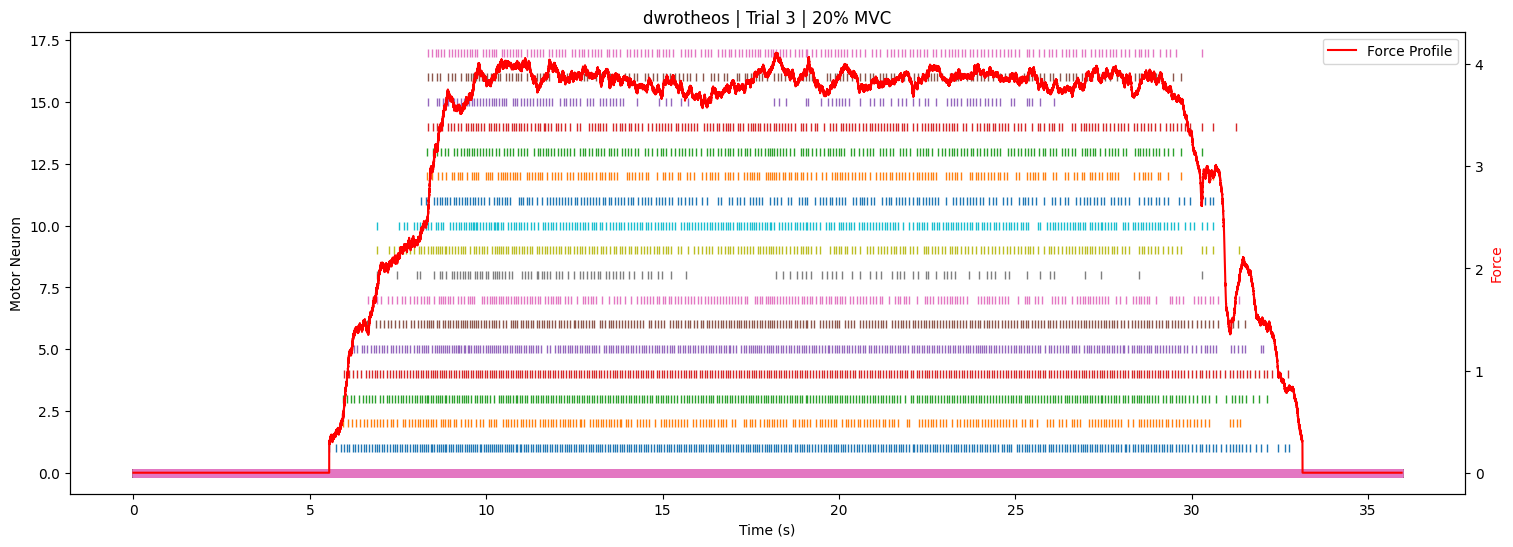

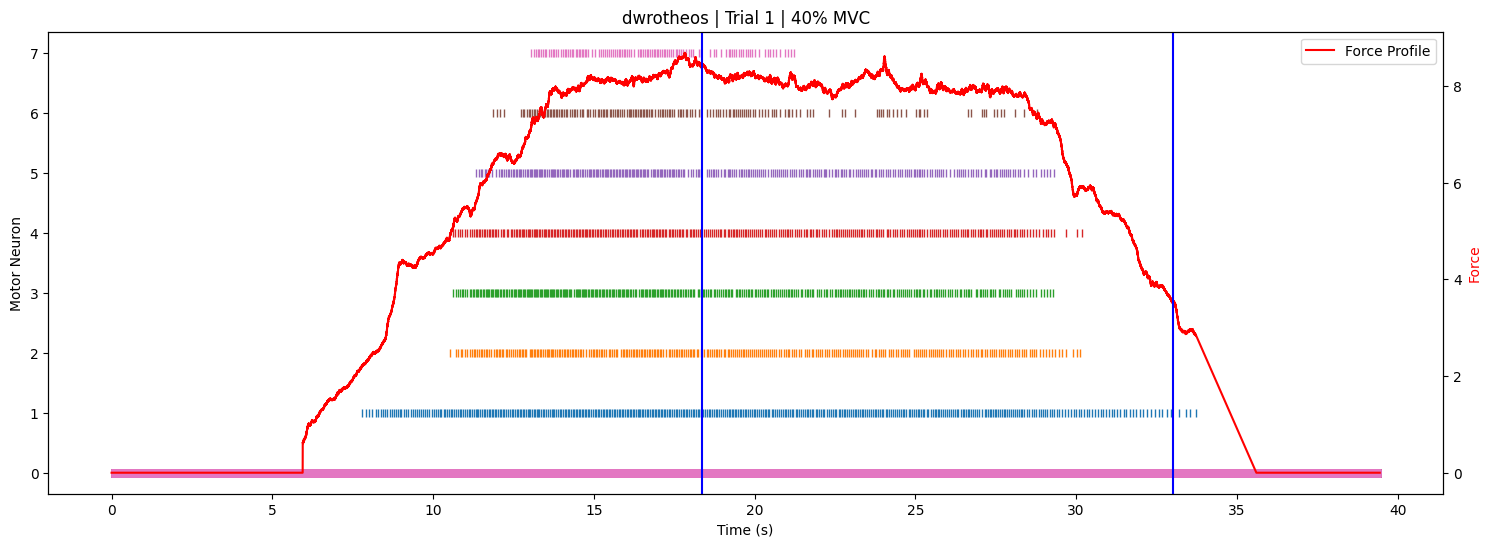

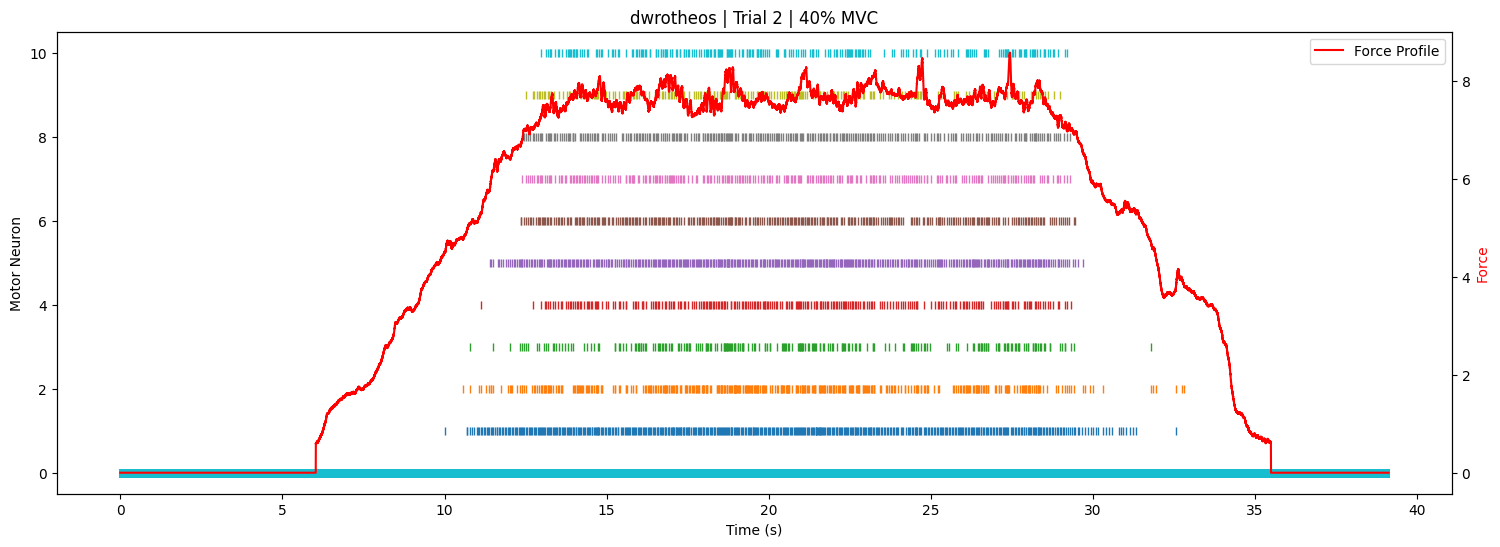

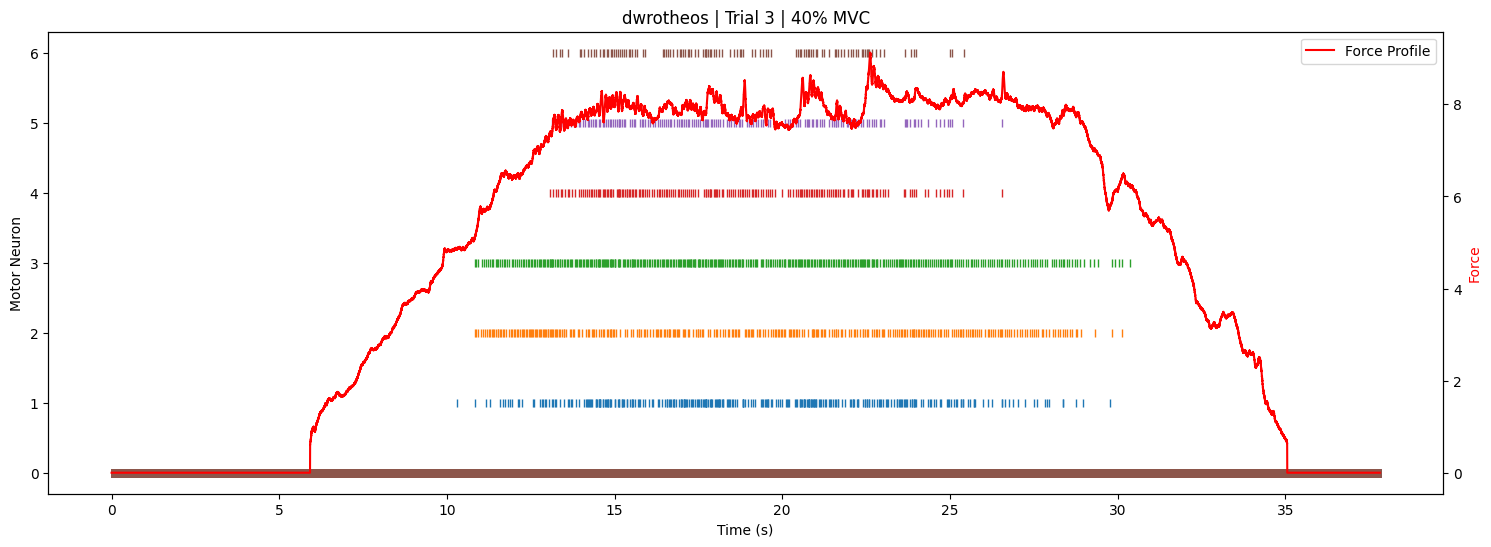

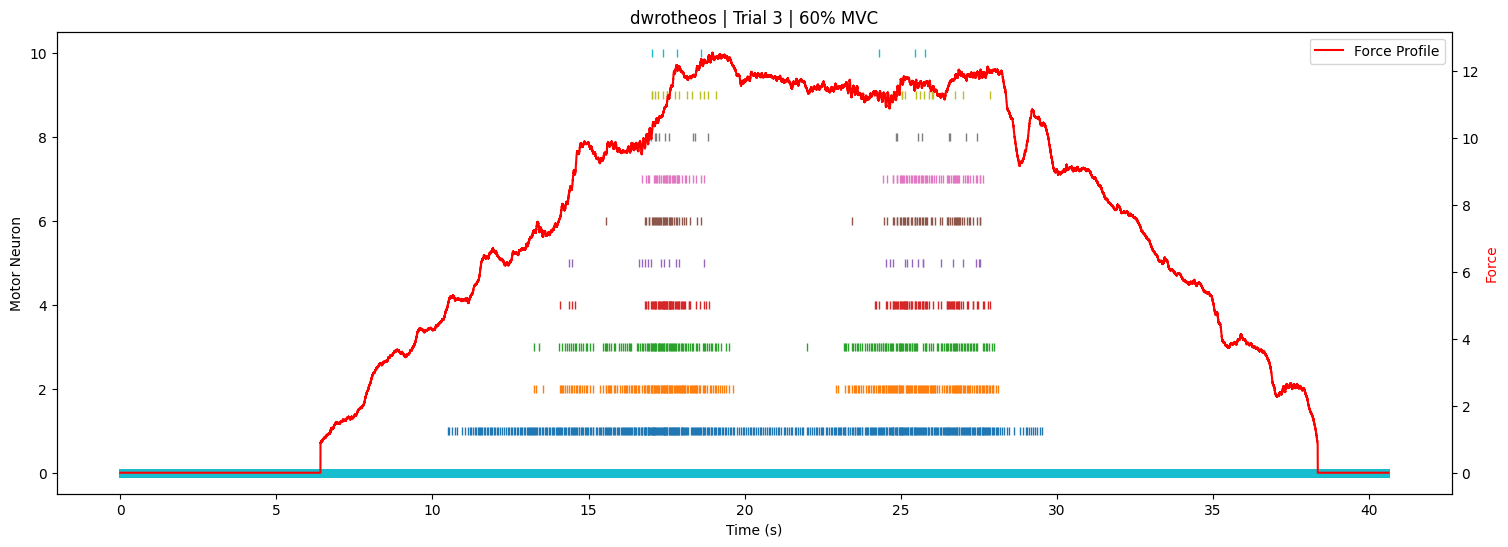

In [ ]:
import globals.visualization
importlib.reload(globals.visualization)
from globals.visualization import visualize_subject, visualize_trial

visualize_subject(df, 'dwrotheos')
# visualize_trial(df, subject='dwrotheos', mvc_level=5, trial_number=3, vmarkers=[(80750-4168)/2048])